# Fulfillment Root-Cause Analysis

**Business question:** What is most associated with late delivery: seller handling, carrier transit, or promise-setting?

This notebook keeps the analysis intentionally focused:

1. **When did delivery performance worsen?**
2. **Which fulfillment component moved with the problem?**
3. **Where is the problem concentrated?**
4. **Do the conclusions survive a simple robustness check?**

All delivery classifications and durations come from the certified SQL metric layer. The notebook analyzes those metrics rather than redefining them.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

from python.scripts.config import connect

from python.scripts.fulfillment_root_cause import (
    COMPARABLE_LABEL,
    load_extracts,
    order_component_spot_checks,
    outlier_sensitivity,
)

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

conn = connect()
frames = load_extracts(conn)

month = frames["fulfillment_month"].copy()
month["purchase_month"] = pd.to_datetime(month["purchase_month"])
month = month[month["is_comparable_trend_window"]].sort_values("purchase_month")

decomp = frames["fulfillment_decomposition"]
decomp = decomp[decomp["analysis_period"] == "comparable_trend_window"].copy()

segments = frames["segment_performance"].copy()

print("Analysis window:", COMPARABLE_LABEL)
print(f"Eligible orders: {month['delivery_performance_eligible'].sum():,.0f}")
print(f"Late orders: {month['late_count'].sum():,.0f}")
print(
    "Overall late rate:",
    f"{month['late_count'].sum() / month['delivery_performance_eligible'].sum():.2%}",
)


Analysis window: 2017-02-01 through 2018-08-31
Eligible orders: 95,453
Late orders: 6,509
Overall late rate: 6.82%


## 1. When did delivery performance worsen?

Start with the marketplace trend. The useful question is not whether some orders were late, but whether lateness was **stable or concentrated in particular periods**.


,purchase_month,delivery_performance_eligible,late_count,late_delivery_rate
18,2018-03-01,7003,1328,0.190
17,2018-02-01,6555,926,0.141
14,2017-11-01,7288,904,0.124
15,2017-12-01,5513,411,0.075
20,2018-05-01,6749,443,0.066


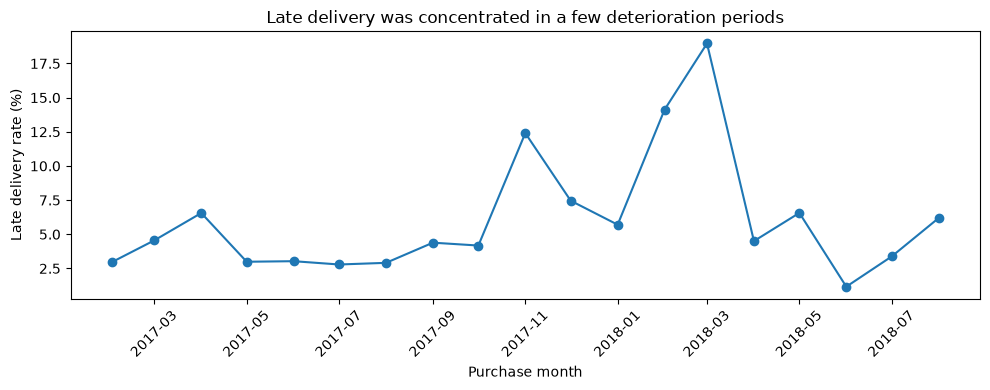

In [2]:
worst_months = (
    month.nlargest(5, "late_delivery_rate")[
        ["purchase_month", "delivery_performance_eligible", "late_count", "late_delivery_rate"]
    ]
    .sort_values("late_delivery_rate", ascending=False)
)

display(worst_months)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(month["purchase_month"], month["late_delivery_rate"] * 100, marker="o")
ax.set(
    title="Late delivery was concentrated in a few deterioration periods",
    xlabel="Purchase month",
    ylabel="Late delivery rate (%)",
)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


## 2. What changed when orders were late?

Now separate the fulfillment process into three operational pieces:

- **Seller handling:** time before carrier handoff
- **Carrier transit:** time from carrier handoff to customer delivery
- **Promise window:** time the customer was originally given

Two views are useful:

- compare typical early/on-time/late orders;
- see which monthly component moves most closely with the late rate.

The correlations below are descriptive signals, not causal effects.


,delivery_class,eligible_orders,median_seller_handling_days,median_carrier_transit_days,median_promised_window_days,median_purchase_to_delivery_days
0,early,87654,1.777,6.926,24.000,9.703
1,late,6509,3.073,26.171,23.000,31.209
2,on_time,1290,2.778,15.194,20.000,20.358


,correlation_with_monthly_late_rate
Promise window,-0.152
Seller handling,0.506
Total fulfillment,0.680
Carrier transit,0.746


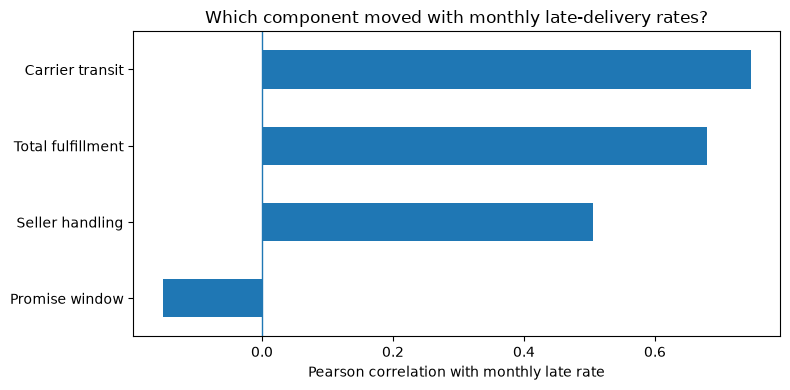

In [3]:
component_table = decomp[
    [
        "delivery_class",
        "eligible_orders",
        "median_seller_handling_days",
        "median_carrier_transit_days",
        "median_promised_window_days",
        "median_purchase_to_delivery_days",
    ]
].sort_values("delivery_class")

display(component_table)

component_cols = {
    "Seller handling": "median_seller_handling_days",
    "Carrier transit": "median_carrier_transit_days",
    "Promise window": "median_promised_window_days",
    "Total fulfillment": "median_purchase_to_delivery_days",
}

correlations = pd.Series(
    {
        label: month["late_delivery_rate"].corr(month[column])
        for label, column in component_cols.items()
    },
    name="correlation_with_monthly_late_rate",
).sort_values()

display(correlations.to_frame())

fig, ax = plt.subplots(figsize=(8, 4))
correlations.plot(kind="barh", ax=ax)
ax.axvline(0, linewidth=1)
ax.set(
    title="Which component moved with monthly late-delivery rates?",
    xlabel="Pearson correlation with monthly late rate",
    ylabel="",
)
fig.tight_layout()
plt.show()


## 3. Where is the operational impact concentrated?

A high late rate is not automatically the biggest marketplace problem. Operations also cares about **scale**.

The state view below keeps only sufficiently sized segments and compares:

- late-delivery rate;
- number of eligible orders;
- number of late orders.

This helps separate high-rate small segments from locations creating substantial marketplace impact.


,state,eligible_units,late_units,late_rate,late_gmv
0,SP,40116,1809,0.045,"268,438.080"
1,RJ,12219,1492,0.122,"213,918.660"
2,MG,11217,519,0.046,"75,837.490"
3,BA,3229,395,0.122,"61,888.840"
4,RS,5275,324,0.061,"43,838.040"
5,SC,3511,290,0.083,"38,054.150"
6,ES,1983,213,0.107,"34,892.780"
7,PR,4841,197,0.041,"29,429.560"
8,CE,1265,175,0.138,"30,570.280"
9,PE,1578,152,0.096,"26,531.400"


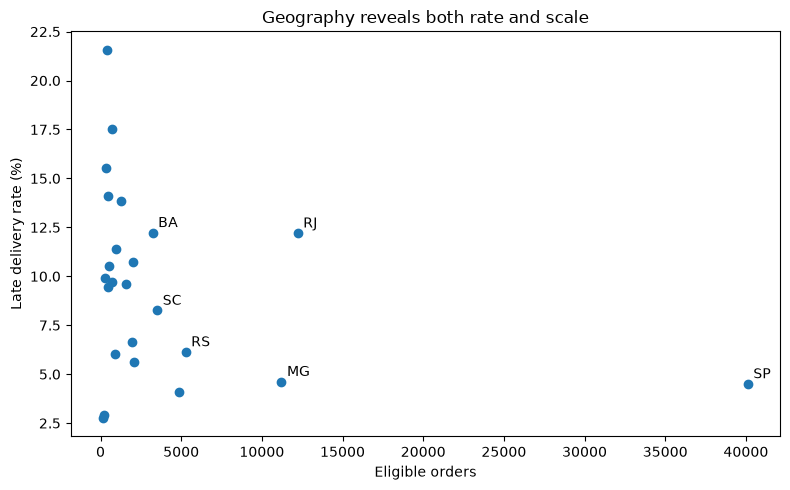

In [4]:
states = segments[
    (segments["segment_type"] == "customer_state")
    & (~segments["is_low_sample"])
].copy()

state_view = (
    states.sort_values("late_units", ascending=False)[
        ["segment_key", "eligible_units", "late_units", "late_rate", "late_gmv"]
    ]
    .head(10)
    .rename(columns={"segment_key": "state"})
)

display(state_view)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(states["eligible_units"], states["late_rate"] * 100)

for _, row in states.nlargest(6, "late_units").iterrows():
    ax.annotate(
        row["segment_key"],
        (row["eligible_units"], row["late_rate"] * 100),
        xytext=(4, 4),
        textcoords="offset points",
    )

ax.set(
    title="Geography reveals both rate and scale",
    xlabel="Eligible orders",
    ylabel="Late delivery rate (%)",
)
fig.tight_layout()
plt.show()


## 4. Does the result depend on extreme delays?

Long-tail delivery times can distort averages and even business conclusions.

As a simple robustness check, compare the certified comparable-window result with versions that exclude the most extreme 1% of transit, handling, or delay values. Then verify a small set of order-level component calculations against the underlying fact table.


In [5]:
sensitivity = outlier_sensitivity(conn)
display(
    sensitivity[
        [
            "slice",
            "eligible_orders",
            "late_count",
            "late_delivery_rate",
            "median_seller_handling_days",
            "median_carrier_transit_days",
        ]
    ]
)

checks = order_component_spot_checks(conn)

max_diffs = pd.Series(
    {
        "handling_days": (
            checks["kpi_seller_handling_days"]
            - checks["source_seller_handling_days"]
        ).abs().max(),
        "transit_days": (
            checks["kpi_carrier_transit_days"]
            - checks["source_carrier_transit_days"]
        ).abs().max(),
        "delay_days": (
            checks["kpi_delivery_delay_days"]
            - checks["source_delivery_delay_days"]
        ).abs().max(),
    },
    name="max_absolute_difference",
)

display(max_diffs.to_frame())


,slice,eligible_orders,late_count,late_delivery_rate,median_seller_handling_days,median_carrier_transit_days
0,all_comparable,95453,6509,0.068,1.843,7.105
1,exclude_p99_transit,94500,5565,0.059,1.839,7.079
2,exclude_p99_handling,94512,6018,0.064,1.820,7.103
3,exclude_p99_delay,94504,5560,0.059,1.835,7.080


,max_absolute_difference
handling_days,0.000
transit_days,0.000
delay_days,0.000


## Takeaways

This analysis is designed to support a small number of operational conclusions rather than produce many charts.

**What the evidence should establish:**

- whether late delivery deteriorated in specific periods rather than uniformly;
- whether seller handling, carrier transit, or promise-setting best tracks those periods;
- which geographies combine poor performance with meaningful volume;
- whether extreme observations materially change the story.

**What this analysis does not establish:**

- that a carrier or seller *caused* the deterioration;
- which seller should receive an intervention first;
- whether changing a promise date would improve customer satisfaction.

Those decisions require the later seller-prioritization and customer-experience analyses.

The strongest root-cause statement should therefore use language such as:

> Delivery deterioration is **most strongly associated with** the fulfillment component and locations that move with late-delivery performance, while robustness checks show whether that pattern survives extreme observations.


In [6]:
conn.close()
